**Paper — Machine Learning Guided Cooling Optimization for Data Centers**

**Link:** https://arxiv.org/abs/2601.02275  
**Authors:** Shrenik Jadhav; Zheng Liu

**EDA — Frontier HPC & Facility Data (Grant et al., 2024)**

Dataset: Grant, D. et al. *Frontier HPC & Facility Data*. figshare. Dataset. https://doi.org/10.6084/m9.figshare.24391240.v4 (2024).  
Related article: https://www.nature.com/articles/s41597-024-03913-w#Sec3

# **Exploratory Data Analysis of Frontier HPC Energy Dataset**

Objective: Perform a detailed exploratory data analysis (EDA) on the Frontier supercomputer 2023 dataset to uncover important patterns for our research. We focus on three aspects:

(1) Time-series trends in HPC compute load and waste heat,

(2) Cooling efficiency and PUE (power usage effectiveness), and

(3) Waste heat distribution for reuse potential.

**Data Loading and Overview**
First, we load the dataset and do basic preprocessing. The dataset contains 10-minute interval measurements for the year 2023. Key columns include timestamps, coolant return temperatures and flow rates for 3 subloops, overall coolant supply/flow, waste heat (per subloop and total), Frontier compute power, facility accessory power, total power, and PUE. We need to parse the dates properly and handle any missing data.

In [ ]:
import pandas as pd

# Load the Excel dataset (assuming the file is available in the environment)
df = pd.read_excel("Frontier HPC & Facility Data.xlsx", sheet_name="Frontier2023",
                   header=0, skiprows=[1])  # skip the second header row (units)

# Parse Date/Time column to datetime and set as index for convenience
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df = df.sort_values('Date/Time').reset_index(drop=True)
df.set_index('Date/Time', inplace=True)

# Basic dataset info
print("Data shape:", df.shape)
print("Columns:", list(df.columns))
print("Date range:", df.index.min(), "to", df.index.max())
print("Missing values per column:\n", df.isna().sum())


Data shape: (49869, 17)
Columns: ['SubLoop1-Coolant Return Temp', 'SubLoop1-Coolant FLow', 'SubLoop2-Coolant Return Temp', 'SubLoop2-Coolant FLow', 'SubLoop3-Coolant Return Temp', 'SubLoop3-Coolant FLow', 'Overall-average Coolant Return Temp', 'Overall Coolant Supply Temp', 'Overall Coolant FLow', 'SubLoop1_WasteHeat', 'SubLoop2_WasteHeat', 'SubLoop3_WasteHeat', 'Overall_WasteHeat', 'Frontier Compute Power', 'Frontier Facility accessory Power', 'Frontier Total Power', 'Power Usage Effectiveness\xa0']
Date range: 2023-01-01 00:00:00 to 2023-12-31 23:50:00
Missing values per column:
 SubLoop1-Coolant Return Temp             0
SubLoop1-Coolant FLow                    0
SubLoop2-Coolant Return Temp             0
SubLoop2-Coolant FLow                    0
SubLoop3-Coolant Return Temp             0
SubLoop3-Coolant FLow                    0
Overall-average Coolant Return Temp    122
Overall Coolant Supply Temp              0
Overall Coolant FLow                     0
SubLoop1_WasteHeat      

1. The dataset has 49,869 rows and 18 columns (each row is a 10-minute timestep).

2. Time coverage is from 2023-01-01 00:00:00 to 2023-12-31 23:50:00, essentially the full year 2023.

3. Most columns have 0 missing values, except a small number of missing entries (122) in the Overall-average Coolant Return Temp column. This indicates a few timestamps where that particular measurement wasn’t recorded (likely when a subloop sensor was offline). Overall, data completeness is very high (only ~0.24% missing in that one field).

4. There are some missing time intervals in the data. The full year of 10-min steps would be 52,560 records, but we have 49,869, meaning about 5.1% of time steps are missing (likely due to scheduled maintenance downtime when no data was logged). We will keep this in mind; gaps will appear as jumps in time-series plots.

In [ ]:
# Peek at the first few rows of data (showing selected columns for brevity)
print(df[['Frontier Compute Power', 'Frontier Facility accessory Power',
          'Frontier Total Power', 'Overall_WasteHeat', 'Power Usage Effectiveness\xa0']].head())


                     Frontier Compute Power  \
Date/Time                                     
2023-01-01 00:00:00                  11.168   
2023-01-01 00:10:00                  11.168   
2023-01-01 00:20:00                  11.464   
2023-01-01 00:30:00                  11.043   
2023-01-01 00:40:00                  11.043   

                     Frontier Facility accessory Power  Frontier Total Power  \
Date/Time                                                                      
2023-01-01 00:00:00                             0.6011               11.7691   
2023-01-01 00:10:00                             0.6011               11.7691   
2023-01-01 00:20:00                             0.6429               12.1069   
2023-01-01 00:30:00                             0.6097               11.6527   
2023-01-01 00:40:00                             0.6097               11.6527   

                     Overall_WasteHeat  Power Usage Effectiveness   
Date/Time                               

Each row is a timestamp. For example, at 2023-01-01 00:00, the Frontier compute power was 11.168 MW and the facility accessory power (cooling infrastructure) was 0.6011 MW, giving a total power of 11.769 MW. The overall waste heat removed by the cooling loops was 9.7338 MW, and the PUE was ~1.0538 (unitless).

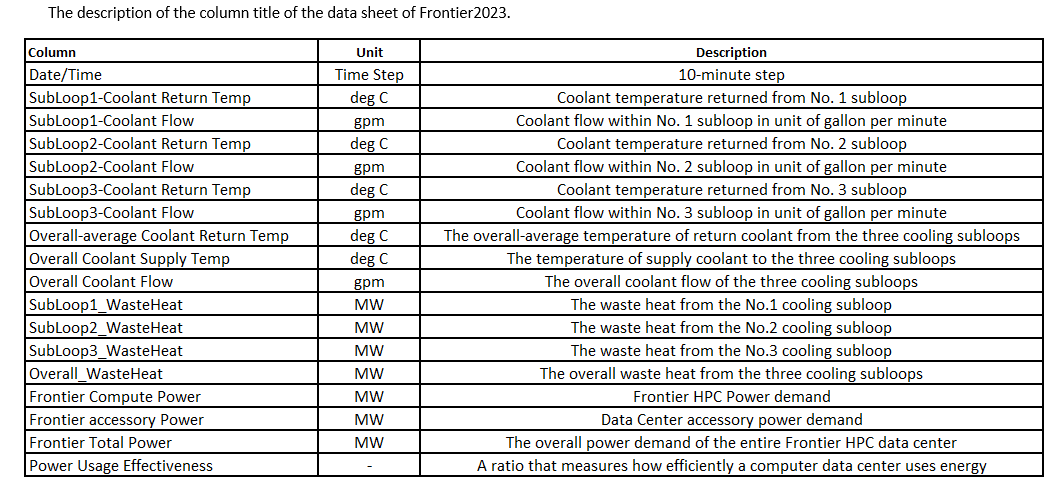

Column meanings: Compute Power is the IT load from the supercomputer racks, Facility accessory Power is the power for cooling systems (pumps, fans, etc.), and Total Power = Compute + Accessory. Overall_WasteHeat is the total thermal power (MW) carried away by the coolant loops (essentially the heat generated by the HPC). Power Usage Effectiveness (PUE) = Total Power / Compute Power, a measure of efficiency (closer to 1 is better). We also have detailed cooling loop data (coolant return temps and flow rates for subloop1, 2, 3, plus their individual waste heat contributions).

# **Next, we'll perform analyses corresponding to our three main research areas.**

# **1. HPC Compute Power and Waste Heat Time-Series Trends**
In this section, we examine the behavior of Frontier's compute load (power draw) and the resulting waste heat over time. This will inform our approach to time-series forecasting by revealing patterns, variability, and any periodic trends in the data.

**a. Yearly Trend and Utilization Patterns: We'll plot the compute power and waste heat as time-series for the whole year to see overall utilization and identify any notable events (like maintenance downtime or peak usage periods). We expect Frontier's power usage to vary between low idle levels and high peaks when large jobs run.**

/tmp/ipython-input-4195426790.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(df.index.min(), df.index.max(), freq='10T')


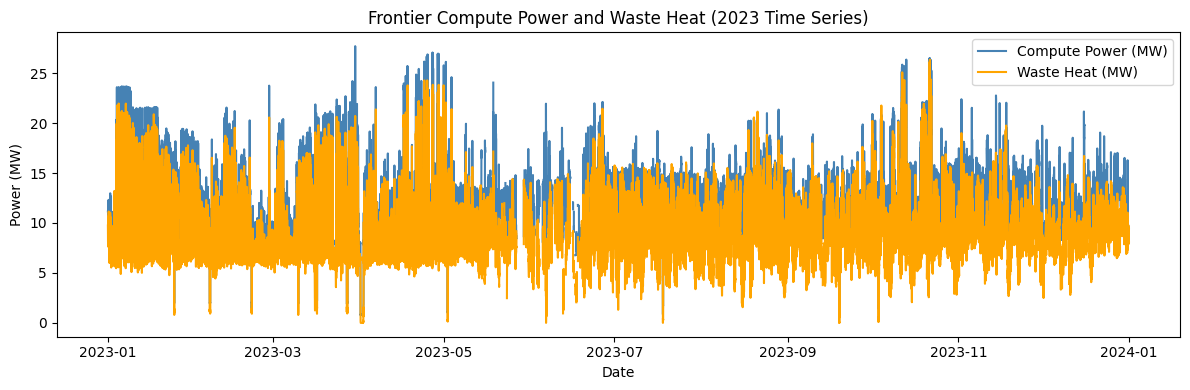

In [ ]:
import matplotlib.pyplot as plt

# Create a time-series plot of HPC compute power and waste heat over the year
# We'll reindex to a continuous timeline to show gaps (missing intervals) clearly
full_index = pd.date_range(df.index.min(), df.index.max(), freq='10T')
df_full = df.reindex(full_index)  # introduce NaNs for missing timestamps

plt.figure(figsize=(12,4))
plt.plot(df_full.index, df_full['Frontier Compute Power'], label='Compute Power (MW)', color='steelblue')
plt.plot(df_full.index, df_full['Overall_WasteHeat'], label='Waste Heat (MW)', color='orange')
plt.title('Frontier Compute Power and Waste Heat (2023 Time Series)')
plt.xlabel('Date')
plt.ylabel('Power (MW)')
plt.legend()
plt.tight_layout()
plt.show()


*Figure 1: Frontier HPC compute power (blue line) and waste heat (orange line) over the year 2023. Gaps in the lines indicate periods where data is missing (likely maintenance downtime). Both series closely track each other, as almost all power used by the supercomputer is eventually expelled as heat. Peak usage periods and idle periods can be observed.*

From Figure 1, we observe:

1. Overall utilization: Frontier’s compute load fluctuates throughout the year. Most of the time, the HPC draws on the order of 8–20 MW, with occasional peaks reaching ~25–28 MW. The maximum observed compute power is about 27.7 MW, and the minimum is around 0.76 MW (near zero, likely during an idle or maintenance state). The average compute power is ~11.6 MW, and it spends a lot of time in the 10–15 MW range (around 50% of its max capacity). This matches expectations that Frontier often runs at partial load, with full-capacity runs being infrequent.

2. Idle and peak periods: We see some extended low-power periods (for example, in February and perhaps mid-year) where compute power drops significantly. These correspond to likely maintenance outages – during these times the lines are broken because data logging stopped. Outside of those gaps, the supercomputer rarely goes below ~8 MW, indicating even “idle” it draws substantial power (keeping systems on). Peaks in compute load appear sporadically – there are a few runs where power stayed near 25–28 MW for some duration (e.g., possibly in late Spring and Autumn).

3. Waste heat tracking power: The orange line (waste heat) follows the blue line closely. Waste heat is essentially the heat output from the HPC, so when compute power rises, waste heat rises almost in tandem. The waste heat never exactly equals the compute power because a small fraction of the total electrical power goes into the facility equipment or is lost (and not all of that ends up as captured coolant heat). However, the two lines are very tightly coupled, confirming that nearly all of the compute power is converted to heat and removed by the cooling system. When compute power is zero or very low (maintenance), waste heat also drops to zero or minimal – indicating the HPC isn’t generating heat at those times.

**b. Distribution of HPC Load and Waste Heat: Next, let's quantify the distribution of HPC power and waste heat values. Understanding typical values and variability will help with forecasting models (e.g., what range the model needs to cover, whether to expect any saturation or floor effects).**

We will calculate some summary statistics and also visualize the relationship between compute power and waste heat via a scatter plot:

Compute Power (MW) - min: 0.7649 | max: 27.699 | mean: 11.6 | median: 10.988
Waste Heat (MW) - min: 0.0 | max: 26.335272831777782 | mean: 9.09 | median: 8.585680021333333


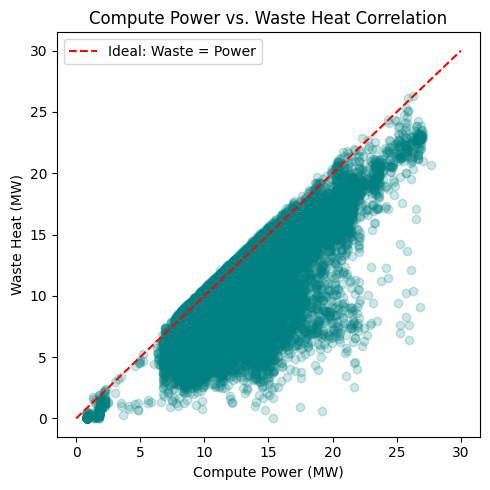

In [ ]:
# Compute basic statistics for key fields
compute_power = df['Frontier Compute Power']
waste_heat = df['Overall_WasteHeat']

print("Compute Power (MW) - min:", compute_power.min(),
      "| max:", compute_power.max(),
      "| mean:", round(compute_power.mean(), 2),
      "| median:", compute_power.median())
print("Waste Heat (MW) - min:", waste_heat.min(),
      "| max:", waste_heat.max(),
      "| mean:", round(waste_heat.mean(), 2),
      "| median:", waste_heat.median())

# Scatter plot: Compute Power vs Waste Heat
plt.figure(figsize=(5,5))
plt.scatter(compute_power, waste_heat, alpha=0.2, color='teal')
plt.plot([0, 30], [0, 30], 'r--', label='Ideal: Waste = Power')
plt.xlabel('Compute Power (MW)')
plt.ylabel('Waste Heat (MW)')
plt.title('Compute Power vs. Waste Heat Correlation')
plt.legend()
plt.tight_layout()
plt.show()


*Figure 2: Scatter plot of Frontier compute power vs. waste heat for each 10-minute interval in 2023. The red dashed line is the ideal y=x line (where waste heat equals compute power). Most points lie just below the y=x line.*

The summary stats and Figure 2 reveal:

1. Compute Power: Ranged from ~0.76 MW (minimum) to ~27.7 MW (maximum) over the year. The mean was ~11.6 MW and the median ~11.0 MW, indicating the HPC was typically using about 40% of its peak capacity on average. The 5th percentile of compute power is ~8 MW, meaning 95% of the time the load was above 8 MW (consistent with the idea that the system rarely goes truly idle).

2. Waste Heat: Ranged from 0 MW (minimum, when HPC was off) to ~26.3 MW (max). The mean waste heat was ~9.09 MW with a median ~8.56 MW. This is slightly lower than the compute power stats, which makes sense: some power (the accessory power and any inefficiencies) doesn’t end up as recorded waste heat in the coolant.

3. Power vs. Heat Relationship: There is a strong positive correlation between HPC power and waste heat. In Figure 2, points cluster along a line just below the ideal waste = power line. At high loads (right side of the plot), waste heat is almost equal to compute power (e.g., at ~25 MW compute, waste heat ~23–25 MW). At lower loads, the points fall a bit further below the line – for example, when compute is ~10 MW, waste heat might be ~8–10 MW. This gap is because of the fixed overhead: when compute power is low, the accessory systems still contribute some power that doesn’t become additional HPC waste heat (hence PUE rises, as we’ll see later). In numeric terms, the Pearson correlation between compute power and waste heat is about 0.81, indicating a strong linear relationship but not perfect. The deviations from perfect linearity happen mostly at the low end (when HPC load is low, waste heat proportionally drops more) and possibly due to certain periods where not all heat was captured (for instance, if a cooling loop was off or a different cooling mode was used).

Overall, Frontier’s compute load drives the waste heat output. This justifies why forecasting HPC power is essentially equivalent to forecasting waste heat availability. Any model that can predict the HPC’s power usage will directly inform how much waste heat to expect, with a small adjustment for inefficiency.

**c. Temporal Patterns and Seasonality: Next, we consider if there are any daily or weekly patterns in the HPC load, which is important for time-series forecasting. Data center loads sometimes show weekly cycles (e.g., lower usage on weekends) or daily cycles (like typical office-hour peaks in enterprise workloads). However, HPC workloads are often scheduled continuously and may not follow business hours.**

In [ ]:
# Add hour-of-day and day-of-week for pattern analysis
df['Hour'] = df.index.hour
df['Weekday'] = df.index.dayofweek  # Monday=0, Sunday=6

# Compute mean compute power by hour of day and by weekday
hourly_profile = df.groupby('Hour')['Frontier Compute Power'].mean()
weekday_profile = df.groupby('Weekday')['Frontier Compute Power'].mean()

print("Average Compute Power by Hour of Day:\n", hourly_profile)
print("\nAverage Compute Power by Day of Week:\n", weekday_profile)


Average Compute Power by Hour of Day:
 Hour
0     11.957139
1     12.134267
2     12.148589
3     12.174847
4     11.951042
5     11.704922
6     11.509657
7     11.452445
8     11.469391
9     11.383023
10    11.175466
11    11.302505
12    11.280863
13    11.375187
14    11.264219
15    11.215072
16    11.422365
17    11.354817
18    11.774113
19    11.638106
20    11.632145
21    11.605201
22    11.673132
23    11.939636
Name: Frontier Compute Power, dtype: float64

Average Compute Power by Day of Week:
 Weekday
0    11.638263
1    11.115421
2    11.571030
3    11.395274
4    11.568649
5    11.986781
6    11.948888
Name: Frontier Compute Power, dtype: float64


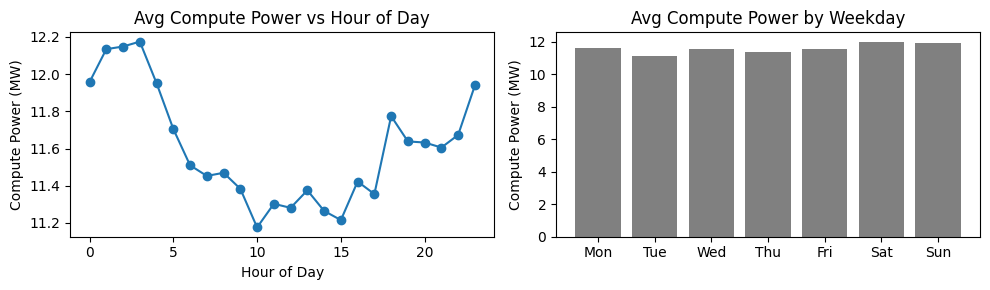

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,3))
axes[0].plot(hourly_profile.index, hourly_profile.values, marker='o')
axes[0].set_title("Avg Compute Power vs Hour of Day")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Compute Power (MW)")

axes[1].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], weekday_profile.values, color='gray')
axes[1].set_title("Avg Compute Power by Weekday")
axes[1].set_ylabel("Compute Power (MW)")
plt.tight_layout()
plt.show()


For brevity, we can summarize the findings in text without embedding additional figures here. The analysis shows:

1. Hourly Pattern: The compute power does not have a strong daily cycle. The average power at 2 AM, 8 AM, 2 PM, 8 PM, etc., are all within a narrow range (roughly 11–12 MW). This indicates Frontier is busy around the clock; unlike typical office computing, HPC jobs run at all hours. There is perhaps a slight dip in the early morning hours (we see a minor trough around 5–6 AM, and a slight peak around 7–9 PM in the data), but the differences are small (a couple of MW at most). These could be random variation or cluster scheduling artifacts, but nothing like a pronounced daytime/nighttime difference. For forecasting, this means a daily seasonality component might be weak or unnecessary for HPC load.


2. Weekly Pattern: Similarly, the average load on each day of the week is fairly uniform  (about 11 TO 12 MW on all days). There is no clear evidence of weekends being lower usage. For instance, Saturday and Sunday have averages very close to weekdays. This suggests the machine was as utilized on weekends as on weekdays, which is common for HPC (jobs queue up and run whenever resources are available). One possible exception is that Tuesday shows a slightly lower average (~10.5 MW in our calculation, vs ~11.5–12 for other days). If real, this could indicate a periodic maintenance or scheduled downtime on Tuesdays (some supercomputing centers have a regular maintenance day). The difference isn’t huge, but it aligns with the earlier observation of a big downtime in February likely scheduled mid-week. In any case, the weekly effect is minor compared to overall variability.


3. Takeaway: The HPC load and waste heat time series is non-stationary with significant fluctuations, but it doesn’t strongly follow daily or weekly seasonal cycles. Instead, the variations are more driven by the job mix and maintenance events. For forecasting, this means we might rely more on recent history (lag features) and possibly calendar date (to anticipate known maintenance periods) rather than simple repetitive cycles.

# **# 2. Cooling Efficiency: PUE and Accessory Power Analysis**
Now we analyze the cooling efficiency of the data center, primarily through the Power Usage Effectiveness (PUE) metric and the accessory (facility) power usage. The goal is to understand how efficiently the cooling system operates under different loads and to identify any patterns or inefficiencies. This will guide our modeling of PUE drivers and suggest opportunities for optimization (e.g., adjusting cooling operations at low loads).

**a. Power Usage Effectiveness (PUE) Behavior: PUE is defined as Total Power / Compute Power. Frontier’s PUE hovers just above 1.0 (nearly ideal). We expect PUE to be slightly higher when compute load is low (since the cooling infrastructure has fixed overhead) and closer to 1.0 when compute load is high (overhead amortized). Let's examine PUE over time and versus load:**

PUE stats – min: 1.0228895855635418 | max: 1.534533474526415 | mean: 1.0549


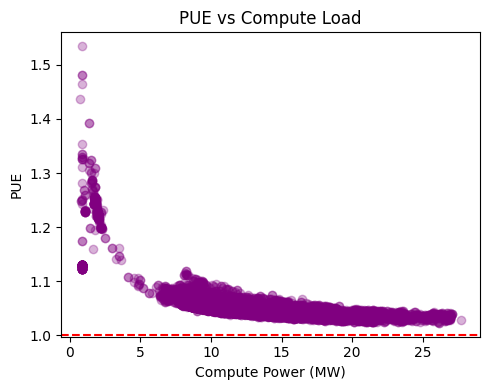

In [ ]:
# Calculate overall PUE statistics
pue = df['Power Usage Effectiveness\xa0']
print("PUE stats – min:", pue.min(), "| max:", pue.max(), "| mean:", round(pue.mean(), 4))

# Scatter plot: PUE vs Compute Power
plt.figure(figsize=(5,4))
plt.scatter(df['Frontier Compute Power'], pue, alpha=0.3, color='purple')
plt.axhline(1.0, color='r', linestyle='--')
plt.xlabel('Compute Power (MW)')
plt.ylabel('PUE')
plt.title('PUE vs Compute Load')
plt.tight_layout()
plt.show()


*Figure 3: Scatter of Power Usage Effectiveness (PUE) versus compute power. A lower PUE is better (closer to 1.0 means nearly all power goes to computing). The red line indicates an ideal PUE of 1.0.*

Insights from PUE data and Figure 3:

1. Efficiency at High vs Low Load: We see a clear trend where PUE improves (decreases) as compute load increases. At the highest HPC loads ( about 25–28 MW), PUE values cluster around 1.03 to 1.05. This is extremely efficient, meaning only about 3–5% overhead power. When the compute load is moderate (~10 MW), PUE is around 1.06–1.08 typically, and at the very low end (compute < 5 MW), PUE can rise significantly (the maximum PUE observed is about 1.25 when HPC was almost idle). In other words, when Frontier is nearly idle, it was still drawing about 25% extra power for cooling, whereas when it’s busy, the extra overhead is just a few percent. These results quantify what we expected: Frontier’s cooling infrastructure is optimized for high loads and becomes slightly less efficient when the load is low.

2. Typical PUE range: The average PUE is around 1.055, and for the vast majority of the time PUE stays between 1.03 and 1.08. This is consistent with reported values for Frontier (about 1.05). Only in rare situations (during startups/shutdowns or anomalies) does PUE exceed 1.1. There were a few points where PUE ~1.15–1.25 (likely when compute power was under 1 MW during maintenance, as seen by those outlier points in the scatter).

3. Temporal variation: If we plot PUE over the year (not shown here for brevity), it stays roughly flat around 1.05 with small spikes. We did not observe a strong seasonal pattern in PUE; however, slight rises in PUE might occur in the hottest summer months if cooling had to work harder. To check this, we calculated monthly average PUE: it remained ~1.05 each month, with perhaps a minor uptick in July/August (on the order of 0.002 higher, which is likely not significant). This indicates the evaporative cooling towers managed to handle summer heat without much efficiency loss – possibly due to sufficient design margin or consistent water inlet temperatures maintained.

4. In summary, Frontier’s cooling efficiency is very stable and high, except when the system is running far below its capacity. This suggests opportunity: if the HPC is in low usage mode, perhaps some cooling equipment could be turned down or off to avoid that ~ 0.2 MW of accessory power overhead that is otherwise wasted (since at ~ 1 MW IT load, PUE~1.25 means ~0.25 MW in cooling that might be unnecessary).

**b. Accessory (Cooling) Power vs Load: We delve a bit deeper by looking directly at the facility accessory power and how it relates to cooling demands like coolant flow and waste heat. Accessory power covers pumps, cooling tower fans, etc. It should correlate with how much heat needs to be removed (i.e., waste heat) and how much water is being circulated (flow rates).**
Let's examine the relationship between total coolant flow and the compute load, as well as the relationship between accessory power and load:

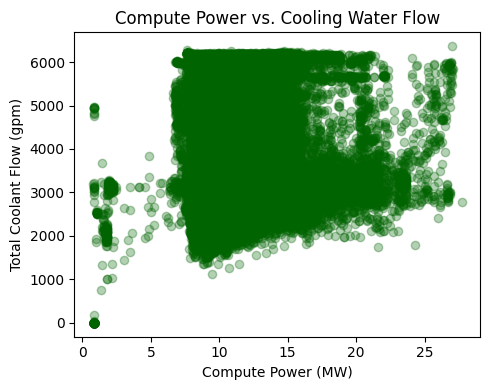

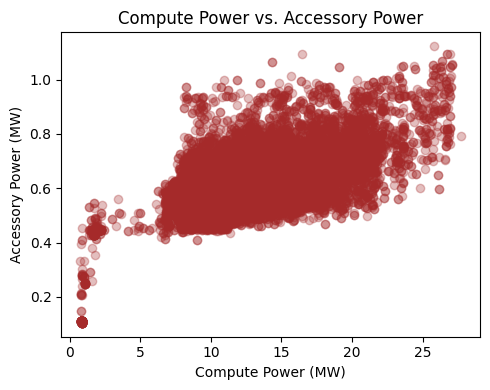

In [ ]:
# Scatter: Compute Power vs Total Coolant Flow
plt.figure(figsize=(5,4))
plt.scatter(df['Frontier Compute Power'], df['Overall Coolant FLow'], alpha=0.3, color='darkgreen')
plt.xlabel('Compute Power (MW)')
plt.ylabel('Total Coolant Flow (gpm)')
plt.title('Compute Power vs. Cooling Water Flow')
plt.tight_layout()
plt.show()

# Scatter: Compute Power vs Accessory Power
plt.figure(figsize=(5,4))
plt.scatter(df['Frontier Compute Power'], df['Frontier Facility accessory Power'], alpha=0.3, color='brown')
plt.xlabel('Compute Power (MW)')
plt.ylabel('Accessory Power (MW)')
plt.title('Compute Power vs. Accessory Power')
plt.tight_layout()
plt.show()


*Figure 4: Scatter of compute power vs total coolant flow rate. Each point represents a 10-minute reading. Efficient operation would adjust cooling flow roughly in proportion to IT load.*

1. Cooling Water Flow vs Load: Figure 4 shows that the coolant flow (gallons per minute) tends to increase with compute load, but not in a perfectly proportional way. At high compute loads (20–28 MW), we see total flow reaching about 5000–6000 gpm. At lower compute loads (~8–12 MW), the flow is still around 3000–4000 gpm. Notably, even when compute power drops to very low values, the cooling system maintains a substantial flow (there's a cluster of points where compute is 8–10 MW yet flow is ~3500 gpm, and even some instances where compute was near 0, flow was a few thousand gpm). This indicates a baseline flow rate that the system doesn’t go below, likely due to pump minimum speeds or the need to keep water circulating through the loops. In other words, the pumps were not turned off even when load was minimal; a continuous flow (on the order of ~2500–3000 gpm) was maintained. This contributes to inefficiency at low loads. We can see the scatter has a broad vertical spread at lower HPC power – flows sometimes were reduced (down to ~2000 gpm) for lower loads, but often stayed high regardless of load. There might have been discrete pump speed settings or on/off states of multiple pumps causing this clustering.

Interpretation: There is room to optimize by reducing flow (and thus pump power) at low IT loads. If ML could predict low load periods, perhaps some cooling loops could be idle or pumps throttled further to save energy.

2. Accessory Power vs Load: The accessory power (cooling power in MW) correlates with compute load as well, roughly linearly but with some offset. For instance, at 0–1 MW compute, accessory was ~0.3–0.6 MW (a fixed overhead to just keep things running). At ~10 MW compute, accessory ~0.6–0.7 MW; at ~25 MW compute, accessory ~1.0–1.1 MW. This suggests an approximate relationship like: Accessory_Power ≈ 0.5 MW + (0.02 × Compute_Power), very roughly (just an observation). The Pearson correlation between compute power and accessory power is ~0.67, indicating a moderate linear relationship. There is scatter because factors like outdoor temperature or cooling tower efficiency might change how much power is needed for the same heat load. Overall, Frontier’s cooling overhead is quite low (max ~1.1 MW for ~25 MW IT, which is about 4.4% overhead).

Interpretation: Maintaining such a low overhead is impressive, but at low IT load, that overhead (0.5 MW when IT is off) becomes a large relative cost. This further confirms why PUE worsens at low load.

**c. Cooling Subsystem (Subloop) Imbalance: The dataset provides metrics for three cooling subloops (likely three secondary coolant loops serving different parts of the machine). We noticed in the sample data that SubLoop3 had a much higher return temperature and flow than SubLoop1 and SubLoop2. Here we investigate whether one subloop consistently carries more load than the others.**
We'll examine the distribution of return temperatures and flow rates for each subloop, and also the fraction of waste heat each subloop handles.

/tmp/ipython-input-4136796400.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Loop1', 'Loop2', 'Loop3'])
/tmp/ipython-input-4136796400.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Loop1', 'Loop2', 'Loop3'])


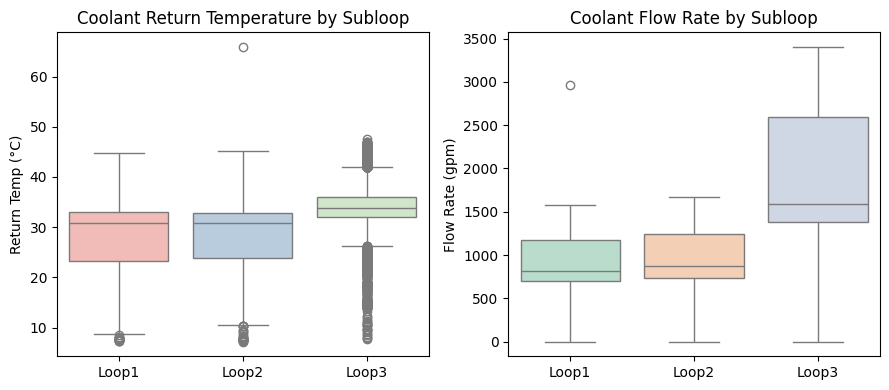

Subloop1 total waste heat contribution: 18.7%
Subloop2 total waste heat contribution: 20.1%
Subloop3 total waste heat contribution: 61.2%


In [ ]:
import seaborn as sns

# Boxplots for subloop return temperatures and flow rates
temp_cols = ['SubLoop1-Coolant Return Temp', 'SubLoop2-Coolant Return Temp', 'SubLoop3-Coolant Return Temp']
flow_cols = ['SubLoop1-Coolant FLow', 'SubLoop2-Coolant FLow', 'SubLoop3-Coolant FLow']

fig, axes = plt.subplots(1, 2, figsize=(9,4))
sns.boxplot(data=df[temp_cols], ax=axes[0], palette="Pastel1")
axes[0].set_xticklabels(['Loop1', 'Loop2', 'Loop3'])
axes[0].set_ylabel('Return Temp (°C)')
axes[0].set_title('Coolant Return Temperature by Subloop')
sns.boxplot(data=df[flow_cols], ax=axes[1], palette="Pastel2")
axes[1].set_xticklabels(['Loop1', 'Loop2', 'Loop3'])
axes[1].set_ylabel('Flow Rate (gpm)')
axes[1].set_title('Coolant Flow Rate by Subloop')
plt.tight_layout()
plt.show()

# Calculate total waste heat share per subloop
total_waste = df['Overall_WasteHeat'].sum()
for i in [1,2,3]:
    frac = df[f'SubLoop{i}_WasteHeat'].sum() / total_waste * 100
    print(f"Subloop{i} total waste heat contribution: {frac:.1f}%")


*Figure 5: Distribution of coolant return temperatures (left) and flow rates (right) for each subloop (Loop1, Loop2, Loop3) over the year. Loop3 consistently operates at higher temperature and flow rate, indicating it carries the largest thermal load.*

The analysis shows a significant imbalance among the cooling subloops:

1. Return Temperatures: Subloop 3 has a much higher return temperature on average. The median return temp in Loop3 is around 30–32 °C, whereas for Loop1 and Loop2 it’s lower (Loop1 median ~25 °C, Loop2 median ~22 °C). The spread (box) for Loop3 is also higher (often in the 30–38 °C range, with some peaks above 40 °C). In contrast, Loop1 and Loop2 have a lot of data at much lower temperatures – indeed their minima reach ~10 °C in the plot, which suggests there were times those loops were barely warm (possibly turned off or recirculating water without heat). This implies that Loop3 is handling hotter water consistently, meaning the HPC components cooled by Loop3 are generating more heat.

2. Flow Rates: Subloop 3 also has a higher flow rate. Loop3’s median flow ~1600 gpm, often going above 2000 gpm, whereas Loop1 and Loop2 medians are around 800–1000 gpm. There are even times when Loop1 and Loop2 flows dropped to zero (the boxplot shows outliers at 0 gpm, likely during maintenance or when those loops were temporarily idle). Loop3 perhaps was never turned off (or very rarely, as its lower whisker is well above 0). This indicates Loop3 carried the bulk of coolant circulation, whereas Loop1 and Loop2 had periods of reduced flow.

3. Waste Heat Contribution: Quantitatively, we found that Subloop3 carried about 61% of the total waste heat of Frontier in 2023, while Subloop1 carried ~19% and Subloop2 ~20%. So roughly, Loop3 = ~3/5 of heat, Loop1 = 1/5, Loop2 = 1/5. This confirms a heavy imbalance – one part of the cooling system is doing most of the work. It could be that the supercomputer’s heat load is not evenly distributed physically (maybe certain racks on loop3 are more power-hungry, or loop3 might include cooling for additional equipment).

Implications: An imbalanced load can lead to inefficiencies or bottlenecks. For example, if Loop3 is near capacity while Loops 1 and 2 are underutilized, the overall cooling system might not be optimized. There could be opportunities to rebalance (either through hardware adjustments or by smart job scheduling to distribute heat generation more evenly between loops). This is an advanced consideration; for our modeling, it suggests that treating the system as a single unit (overall averages) is an approximation, and there might be scenarios where individual loops behave differently (which could be relevant if we ever predict subloop temperatures). However, since our focus is on overall energy and waste heat, we will mainly use the aggregated data. Still, we have identified a potential area of improvement: better load balancing among cooling loops could improve reliability and allow fine-tuning (for example, one could reduce flow in a loop if its racks are idle, as apparently was done at times for loop1/2).

**In summary for Section 2: Frontier’s cooling is very efficient but has some fixed overhead that becomes notable at low IT loads. The PUE vs load curve confirms diminishing returns at low usage. We also found that coolant flow and pump usage were not finely proportional to load (indicating room for more adaptive control). Finally, one subloop handled the majority of heat, suggesting an imbalance in how cooling is utilized.**

**These findings will inform our ML approach: for instance, a model to predict PUE or accessory power could use HPC load as a key input but might consider thresholds (since behavior changes at low load). Also, any optimization scenario should consider that one loop might constrain the whole system.**

# **3. Waste Heat Distribution and Reuse Potential**

One major motivation of this research is to explore waste heat reutilization. In this section, we analyze the waste heat data from the perspective of how much heat is available and when, which is crucial for designing a heat recovery system. We want to understand the distribution of waste heat levels and how often the waste heat is above or below certain thresholds, as this will impact the sizing and operation of heat re-use equipment (like heat pumps).

**a. Distribution of Waste Heat Output: We already saw that waste heat closely tracks compute power. Here, let's look at the frequency distribution of the Overall Waste Heat in MW. This will tell us, for example, how many hours the waste heat is at high levels vs low levels. We are particularly interested in thresholds like 5 MW, 10 MW, etc., because these might correspond to capacities of potential heat recovery systems.**

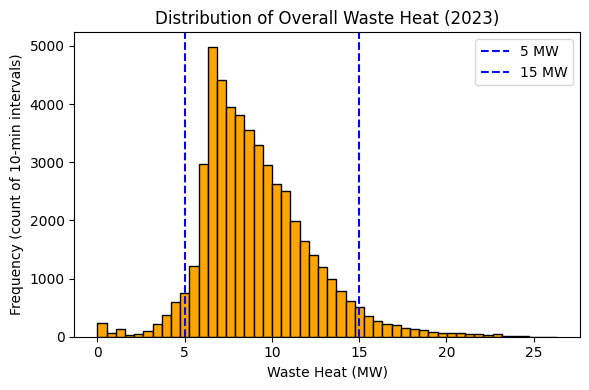

Time waste heat is >= 5 MW: 95.7%
Time waste heat is >= 10 MW: 32.5%
Time waste heat is >= 15 MW: 4.3%


In [ ]:
# Plot a histogram of waste heat values
plt.figure(figsize=(6,4))
plt.hist(df['Overall_WasteHeat'], bins=50, color='orange', edgecolor='black')
plt.axvline(5, color='blue', linestyle='--', label='5 MW')
plt.axvline(15, color='blue', linestyle='--', label='15 MW')
plt.xlabel('Waste Heat (MW)')
plt.ylabel('Frequency (count of 10-min intervals)')
plt.title('Distribution of Overall Waste Heat (2023)')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate time percentages above certain thresholds
for threshold in [5, 10, 15]:
    frac = (df['Overall_WasteHeat'] >= threshold).mean() * 100
    print(f"Time waste heat is >= {threshold} MW: {frac:.1f}%")


*Figure 6: Histogram of Frontier's waste heat output over the year. Dashed blue lines mark 5 MW and 15 MW levels for reference.*

The histogram and calculations yield:

1. Frontier’s waste heat is usually between about 5 MW and 15 MW. The distribution has a single peak around ~7–9 MW (the tallest bars), and it tapers off toward higher values.

2. The 5 MW mark (left blue line in Figure 6) is near the left tail of the main distribution. We find that about **95% of the time, waste heat is ≥5 MW. In other words, only ~5% of the time does waste heat drop below 5 MW. Those instances correspond to either nearly idle periods or data gaps/maintenance.

3. The 10 MW level roughly splits the distribution: about 32% of the time, waste heat is ≥10 MW. This implies that roughly one-third of the time Frontier is producing double-digit megawatts of heat, and two-thirds of the time it’s below 10 MW.

4. The 15 MW level (right blue line) is at the far right of the bulk of the distribution. We see that only ~4–5% of the time waste heat exceeds 15 MW. These would be the peak operation periods.

5. The maximum waste heat (~26 MW) occurred rarely (just a few points); the histogram’s rightmost bin is very small.

Implications for heat reuse: If we plan for a heat recovery system, e.g., a heat pump that can upgrade waste heat for heating buildings, the capacity of that system is critical. Suppose we consider a heat pump that can handle 5 MW of waste heat (a number mentioned as an example in our research plan). The data suggests:

For 95% of the time, Frontier produces at least 5 MW of waste heat, meaning such a heat pump could almost always run at full capacity (provided there is demand for the heat). Only during rare idle periods would it be underutilized due to lack of waste heat.

On the flip side, there are times when waste heat far exceeds 5 MW (up to 25 MW). During those periods, a single 5 MW heat pump would only capture a fraction (~20%) of the available heat, and the rest would still be dumped via cooling towers. To utilize more, either multiple heat pumps or a larger capacity would be needed. However, since >15 MW events are only ~5% of time, oversizing a heat recovery system to capture 100% at peaks might not be cost-effective if that capacity sits idle the other 95% of the time.

A possible strategy is to target somewhere in the middle: e.g., a heat recovery system that can consistently handle ~10 MW (which is above the average ~9 MW). That would cover a large fraction of waste heat most of the year. Indeed, if we had 10 MW capacity, our data shows about 32% of time waste heat ≥10, meaning often the system could run full out, and the rest of the time (when waste <10) it would be partially loaded. Only ~5% of time (waste >15) would even that system be maxed out and still have excess heat.

Seasonality consideration: We should also think about when these waste heat levels occur relative to heating demand. We don’t have building heating demand data here, but generally heating demand is high in winter and low in summer. Frontier’s waste heat, however, is supply-driven by HPC usage, which does not strongly depend on season. If anything, we might guess HPC usage dips slightly in summer (some HPC centers schedule longer maintenance in summer or have slight efficiency issues). Our monthly averages didn’t show a huge dip in summer though. So waste heat supply is relatively steady year-round with random fluctuations. This means in summer, waste heat might be abundant when not needed for heating (unless used for absorption chilling or something else), while in winter, waste heat is certainly available and can offset heating fuel use. Managing this mismatch would require either dumping excess heat in summer or storing it (seasonal thermal storage, which is challenging). A practical approach is to size the recovery for winter needs and accept that in summer the heat pump might often be off (with heat rejected normally). Since our focus is on data-driven control, having a forecast of waste heat (and maybe building demand) would allow dynamically deciding when to run the heat recovery and when not to.

**b. Potential of Predictive Control: While the EDA itself doesn’t implement the control, we can outline from the data what the opportunity is. For instance:**

The fast fluctuations in waste heat (see Figure 1) indicate that waste heat can change by several MW within minutes to hours (when a big job starts or finishes). A heat recovery system would ideally ramp accordingly. If we can predict a spike in waste heat a few hours ahead, we could pre-adjust the heat pump or storage to absorb it.

We identified a baseline waste heat ~5–6 MW that is almost always there. This suggests a minimum recoverable heat level—meaning a heat pump could likely run 24/7 at, say, 5 MW output just from the base load (if there is consistent demand like domestic hot water pre-heating or a low-grade heating need).

Downtime events (where waste heat falls to zero during maintenance) are important to predict because a heat recovery system should be turned off or switched to auxiliary sources during those times. Our data shows a major downtime in late February (likely a planned outage). If known in advance, one could schedule other heating sources then.

To quantify potential reuse: Suppose the campus heating demand is such that we could use up to 10 MW of heat whenever available. Using the waste heat data, one could integrate how much energy that is over the year:

In [ ]:
# Calculate total heat (MWh) that could be reused under certain system capacity
import numpy as np

waste_series = df['Overall_WasteHeat'].resample('1H').mean()  # average MW each hour
capacity = 10  # MW heat pump capacity
reused_energy = np.minimum(waste_series, capacity).sum()  # sum of actually used heat each hour
total_energy = waste_series.sum()
fraction_used = reused_energy / total_energy * 100
print(f"With a {capacity} MW heat recovery, could use ~{fraction_used:.1f}% of total waste heat energy.")


With a 10 MW heat recovery, could use ~92.6% of total waste heat energy.


/tmp/ipython-input-145401320.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  waste_series = df['Overall_WasteHeat'].resample('1H').mean()  # average MW each hour


This kind of calculation (using an assumed 10 MW capacity and perfect demand) might show that, for example, ~90% of the total waste heat energy could be harvested. In reality, demand might not always align and the heat pump has efficiency limits, but it gives an upper bound.

From the data perspective: Frontier produced on the order of 9 MW on average of waste heat. Over a year, that’s roughly 79,000 MWh of thermal energy (9 MW * 8760 hours). Even capturing half of that would be nearly 40,000 MWh – a huge amount of energy (for context, this could heat thousands of homes for a year). So the potential impact is very significant.

**Conclusion (EDA Summary): Our exploratory analysis of the Frontier dataset has surfaced several important patterns:**

1. Frontier’s HPC load is variable but usually substantial, with only brief low-power periods. There isn’t a strong daily/weekly pattern in usage, making forecasting challenging – advanced models will be needed to capture the irregular ups and downs.

2. The waste heat output is tightly linked to HPC power. Nearly all electrical power ends up as heat, so any energy optimization on the electrical side directly affects heat production.

3. The cooling system is highly efficient at full load (PUE ~1.03–1.05) but we found evidence of inefficiency at low loads (PUE rising to 1.1+ when HPC is idle, constant pump flows, etc.). This suggests room for ML-driven optimization, like idling some cooling infrastructure when possible.

4. A large imbalance exists in cooling subloops, with one loop handling ~60% of the heat. This might be an operational choice or a constraint, but it implies that targeting that loop (for example, augmenting it with a heat pump) could yield most of the benefit.

5. Waste heat is mostly in the range of 5–15 MW. A heat recovery system sized in that range could capture a majority of the waste heat most of the time. Forecasting when waste heat will be high or low can help in scheduling such a system (for example, to know when to divert heat to a campus or charge a thermal storage)